# Complete LightGBM Track

## Stage 4F — Initial LightGBM Model and Importance Analysis

### 0. Stage 4F Objective

Reason: Stage 4F uses only the saved non-sensitive Discovery sample.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The LightGBM track starts with Test locked.

In [1]:
from pathlib import Path
import json, os
import pandas as pd
from IPython.display import display, Image, Markdown
ROOT = Path.cwd().resolve()
CACHE_ONLY = os.environ.get('STAGE4_LIGHTGBM_CACHE_ONLY', '0') == '1'
assert (ROOT / 'artifacts/reports/stage4g_gate_verification.json').is_file()

def show_json(relative, keys=None):
    value = json.loads((ROOT / relative).read_text(encoding='utf-8'))
    if keys is None:
        display(value)
    else:
        display({key: value.get(key) for key in keys})
    return value

def show_csv(relative, columns=None, rows=10):
    frame = pd.read_csv(ROOT / relative)
    view = frame if columns is None else frame.loc[:, columns]
    display(view.head(rows))
    return frame

print({'project_root': str(ROOT), 'cache_only': CACHE_ONLY, 'fit_calls': 0, 'test_predictions': 0})

### 1. Imports and Configuration

Reason: This section checks the saved evidence for Imports and Configuration.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The notebook is a cache reader and contains no fit call.

In [2]:
print({'cache_reader': True, 'heavy_fit_calls': 0, 'thread_count': 2, 'seed': 42})

{'cache_reader': True, 'heavy_fit_calls': 0, 'thread_count': 2, 'seed': 42}


### 2. Previous-Stage Validation

Reason: This section checks the saved evidence for Previous-Stage Validation.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Every required earlier Stage reports PASS.

In [3]:
reports = {name: json.loads((ROOT / 'artifacts/reports' / name).read_text(encoding='utf-8'))['status'] for name in ['prompt1_verification.json','prompt2_verification.json','stage3_verification.json','stage4a_verification.json','stage4b_verification.json','stage4c_verification.json','stage4de_verification.json']}
display(reports)
assert set(reports.values()) == {'PASS'}

{'prompt1_verification.json': 'PASS',
 'prompt2_verification.json': 'PASS',
 'stage3_verification.json': 'PASS',
 'stage4a_verification.json': 'PASS',
 'stage4b_verification.json': 'PASS',
 'stage4c_verification.json': 'PASS',
 'stage4de_verification.json': 'PASS'}

### 3. Protected File Check

Reason: This section checks the saved evidence for Protected File Check.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Protected source and prior-stage files remain unchanged.

In [4]:
show_json('artifacts/manifests/stage4/lightgbm/stage4g_protected_hashes_after.json', ['file_count','mismatches','status'])

{'file_count': 852, 'mismatches': {}, 'status': 'PASS'}

### 4. Discovery Sample

Reason: This section checks the saved evidence for Discovery Sample.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The exact saved Discovery roles were used.

In [5]:
sample_check = show_json('artifacts/splits/stage4/stage4_sample_verification.json', ['source_train_rows','test_overlap_rows','samples','status'])

{'source_train_rows': 399788,
 'test_overlap_rows': 0,
 'samples': {'discovery': {'rows': 65000,
   'train_rows': 50000,
   'validation_rows': 15000,
   'expected_rows': 65000,
   'row_ids_unique': True,
   'maximum_target_bin_proportion_difference': 8.993074021537706e-06,
   'role_maximum_target_bin_proportion_difference': {'train': 1.2069997098462792e-05,
    'validation': 3.2547250042522236e-05},
   'sha256': '79cf8051552f1edc1e68b9284d0a3ccfb49f5ceb3afd4b767a0da5dee372320e',
   'valid': True},
  'feature_confirmation': {'rows': 100000,
   'train_rows': 80000,
   'validation_rows': 20000,
   'expected_rows': 100000,
   'row_ids_unique': True,
   'maximum_target_bin_proportion_difference': 1.2069997098462792e-05,
   'role_maximum_target_bin_proportion_difference': {'train': 7.06999709847167e-06,
    'validation': 3.2069997098468916e-05},
   'sha256': '2dabbdc5e6b0fee9bc50e63feeb912e3096a5408cafbbf1685c1e00332380cf4',
   'valid': True},
  'final_selection': {'rows': 125000,
   'train_

### 5. LightGBM Feature Packs

Reason: This section checks the saved evidence for LightGBM Feature Packs.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Only the two allowed Stage 4F packs were compared.

In [6]:
packs = show_json('artifacts/features/stage4/boosting_feature_packs.json', ['version'])
display({name: len(packs['packs'][name]['raw']) for name in ['boosting_base_v1','lightgbm_encoded_v1']})

{'version': 'stage4b_initial_boosting_packs_v1_20260714'}

{'boosting_base_v1': 23, 'lightgbm_encoded_v1': 27}

### 6. LightGBM Pipeline

Reason: This section checks the saved evidence for LightGBM Pipeline.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: All learned mappings stayed inside each fitted Pipeline.

In [7]:
show_json('artifacts/checkpoints/stage4/stage4b_lightgbm_smoke.json', ['model','fit_rows','validation_rows','feature_name_count','serialization_reload_match','test_rows','status'])

{'model': 'lightgbm',
 'fit_rows': 4000,
 'validation_rows': 1000,
 'feature_name_count': 35,
 'serialization_reload_match': True,
 'test_rows': 0,
 'status': 'PASS'}

{'stage': 'stage4b',
 'version': 'stage4b_initial_boosting_packs_v1_20260714',
 'model': 'lightgbm',
 'package_available': True,
 'fit_rows': 4000,
 'validation_rows': 1000,
 'total_rows': 5000,
 'iterations_or_trees': 5,
 'fit_seconds': 0.09084140000049956,
 'finite_predictions': True,
 'prediction_count': 1000,
 'feature_name_count': 35,
 'transformed_columns': 35,
 'feature_names_stable': True,
 'serialization_reload_match': True,
 'row_order_preserved': True,
 'source_frames_unchanged': True,
 'representation_sparse': False,
 'test_rows': 0,
 'screening_performed': False,
 'status': 'PASS'}

### 7. Three Required Candidates

Reason: This section checks the saved evidence for Three Required Candidates.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: All three required Candidates completed sequentially.

In [8]:
show_csv('artifacts/results/stage4/lightgbm/initial/lightgbm_initial_screening.csv', ['candidate_id','required','feature_pack','target_mode','mae','rmse','top_decile_mae','best_iteration'], 3)

,candidate_id,required,feature_pack,target_mode,mae,rmse,top_decile_mae,best_iteration
0,candidate_01_base_raw,True,boosting_base_v1,raw,65.313598,139.014434,205.638295,1259
1,candidate_02_encoded_raw,True,lightgbm_encoded_v1,raw,64.604607,138.551284,202.700003,1499
2,candidate_03_encoded_log1p,True,lightgbm_encoded_v1,log1p,64.322391,138.014576,205.739272,1474


,candidate_id,required,feature_pack,target_mode,num_leaves,best_iteration,fit_time_seconds,prediction_time_seconds,mae,mse,...,p90_absolute_error,negative_prediction_rate,mae_usd,rmse_usd,original_scale,top_decile_mae,top_five_percent_mae,underestimation_rate,overestimation_rate,mae_rank
0,candidate_01_base_raw,True,boosting_base_v1,raw,31,1259,3.451557,1.010985,65.313598,19325.012748,...,138.768874,0.004867,65313.598402,139014.433597,True,205.638295,297.261288,0.497067,0.502933,4
1,candidate_02_encoded_raw,True,lightgbm_encoded_v1,raw,31,1499,6.167098,1.251105,64.604607,19196.458397,...,137.067743,0.005067,64604.606623,138551.284357,True,202.700003,292.843458,0.503467,0.496533,2
2,candidate_03_encoded_log1p,True,lightgbm_encoded_v1,log1p,31,1474,6.182766,1.250069,64.322391,19048.023318,...,137.098376,0.000000,64322.390765,138014.576468,True,205.739272,295.859633,0.503533,0.496467,1
3,candidate_04_safer_leaves23_raw,False,lightgbm_encoded_v1,raw,23,1492,5.406063,1.164148,64.904466,19405.596626,...,137.361170,0.005000,64904.466073,139303.972039,True,205.010825,296.783960,0.501867,0.498133,3


### 8. Optional Refinement

Reason: This section checks the saved evidence for Optional Refinement.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The one allowed safer refinement was rejected.

In [9]:
show_csv('artifacts/results/stage4/lightgbm/initial/lightgbm_initial_screening.csv', ['candidate_id','num_leaves','mae','top_decile_mae'], 4).tail(1)

,candidate_id,num_leaves,mae,top_decile_mae
0,candidate_01_base_raw,31,65.313598,205.638295
1,candidate_02_encoded_raw,31,64.604607,202.700003
2,candidate_03_encoded_log1p,31,64.322391,205.739272
3,candidate_04_safer_leaves23_raw,23,64.904466,205.010825


,candidate_id,required,feature_pack,target_mode,num_leaves,best_iteration,fit_time_seconds,prediction_time_seconds,mae,mse,...,p90_absolute_error,negative_prediction_rate,mae_usd,rmse_usd,original_scale,top_decile_mae,top_five_percent_mae,underestimation_rate,overestimation_rate,mae_rank
3,candidate_04_safer_leaves23_raw,False,lightgbm_encoded_v1,raw,23,1492,5.406063,1.164148,64.904466,19405.596626,...,137.36117,0.005,64904.466073,139303.972039,True,205.010825,296.78396,0.501867,0.498133,3


### 9. Candidate Results

Reason: This section checks the saved evidence for Candidate Results.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The encoded raw-target Candidate won under the fixed tie rule.

In [10]:
show_csv('artifacts/results/stage4/lightgbm/initial/lightgbm_initial_screening.csv', ['candidate_id','mae','rmse','rmsle','rmsle_clipped_zero','top_decile_mae','fit_time_seconds'], 4)

,candidate_id,mae,rmse,rmsle,rmsle_clipped_zero,top_decile_mae,fit_time_seconds
0,candidate_01_base_raw,65.313598,139.014434,NaN,0.472937,205.638295,3.451557
1,candidate_02_encoded_raw,64.604607,138.551284,NaN,0.462890,202.700003,6.167098
2,candidate_03_encoded_log1p,64.322391,138.014576,0.400074,0.400074,205.739272,6.182766
3,candidate_04_safer_leaves23_raw,64.904466,139.303972,NaN,0.463411,205.010825,5.406063


,candidate_id,required,feature_pack,target_mode,num_leaves,best_iteration,fit_time_seconds,prediction_time_seconds,mae,mse,...,p90_absolute_error,negative_prediction_rate,mae_usd,rmse_usd,original_scale,top_decile_mae,top_five_percent_mae,underestimation_rate,overestimation_rate,mae_rank
0,candidate_01_base_raw,True,boosting_base_v1,raw,31,1259,3.451557,1.010985,65.313598,19325.012748,...,138.768874,0.004867,65313.598402,139014.433597,True,205.638295,297.261288,0.497067,0.502933,4
1,candidate_02_encoded_raw,True,lightgbm_encoded_v1,raw,31,1499,6.167098,1.251105,64.604607,19196.458397,...,137.067743,0.005067,64604.606623,138551.284357,True,202.700003,292.843458,0.503467,0.496533,2
2,candidate_03_encoded_log1p,True,lightgbm_encoded_v1,log1p,31,1474,6.182766,1.250069,64.322391,19048.023318,...,137.098376,0.000000,64322.390765,138014.576468,True,205.739272,295.859633,0.503533,0.496467,1
3,candidate_04_safer_leaves23_raw,False,lightgbm_encoded_v1,raw,23,1492,5.406063,1.164148,64.904466,19405.596626,...,137.361170,0.005000,64904.466073,139303.972039,True,205.010825,296.783960,0.501867,0.498133,3


### 10. Preliminary Configuration

Reason: This section checks the saved evidence for Preliminary Configuration.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The preliminary configuration is frozen.

In [11]:
show_json('artifacts/results/stage4/lightgbm/initial/lightgbm_preliminary_configuration.json', ['selected_candidate','selection_rule','feature_pack','target_mode','best_iteration','thread_count'])

{'selected_candidate': 'candidate_02_encoded_raw',
 'selection_rule': 'Candidate 3 had 0.437% lower MAE, but the difference was below 0.5%; Candidate 2 had 1.48% lower top-decile MAE and the tie rule prefers raw target when effectively equal.',
 'feature_pack': 'lightgbm_encoded_v1',
 'target_mode': 'raw',
 'best_iteration': 1499,
 'thread_count': 2}

{'stage_id': 'stage4f',
 'stage_name': 'Stage 4F — Initial LightGBM Model and Importance Analysis',
 'selected_candidate': 'candidate_02_encoded_raw',
 'selection_rule': 'Candidate 3 had 0.437% lower MAE, but the difference was below 0.5%; Candidate 2 had 1.48% lower top-decile MAE and the tie rule prefers raw target when effectively equal.',
 'feature_pack': 'lightgbm_encoded_v1',
 'target_mode': 'raw',
 'parameters': {'n_estimators': 1500,
  'learning_rate': 0.05,
  'num_leaves': 31,
  'max_depth': -1,
  'min_child_samples': 50,
  'subsample': 0.8,
  'subsample_freq': 1,
  'colsample_bytree': 0.8,
  'reg_alpha': 0.0,
  'reg_lambda': 5.0,
  'random_state': 42,
  'n_jobs': 2,
  'objective': 'regression_l1',
  'verbosity': -1},
 'best_iteration': 1499,
 'random_seed': 42,
 'thread_count': 2,
 'encoding_policy': 'training-fit frequency encoding plus training-fit ordinal encoding inside the complete Pipeline',
 'test_rows': 0}

### 11. Preliminary Model Saving

Reason: This section checks the saved evidence for Preliminary Model Saving.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Only the selected preliminary bundle was promoted.

In [12]:
show_json('artifacts/manifests/stage4/lightgbm/stage4f_preliminary_model_manifest.json', ['model_path','native_model_path','prediction_path','metrics','status'])

{'model_path': 'artifacts\\models\\lightgbm\\preliminary\\lightgbm_preliminary_without_sensitive.joblib',
 'native_model_path': 'artifacts\\models\\lightgbm\\preliminary\\lightgbm_preliminary_without_sensitive.txt',
 'prediction_path': 'artifacts\\predictions\\lightgbm\\initial\\lightgbm_preliminary_without_sensitive.csv',
 'metrics': {'mae': 64.60460662344825,
  'mse': 19196.458397110997,
  'rmse': 138.55128435749342,
  'mape_percent': 38.90762684701193,
  'r_squared': 0.663108860373976,
  'rmsle': None,
  'rmsle_clipped_zero': 0.4628896928494735,
  'median_absolute_error': 38.01791991371087,
  'wape_percent': 26.20227414524823,
  'mean_signed_error': -9.723597807992691,
  'p90_absolute_error': 137.06774315741663,
  'negative_prediction_rate': 0.005066666666666666,
  'mae_usd': 64604.60662344825,
  'rmse_usd': 138551.28435749342,
  'original_scale': True,
  'top_decile_mae': 202.70000253059425,
  'top_five_percent_mae': 292.84345809387196,
  'underestimation_rate': 0.5034666666666666,

{'stage_id': 'stage4f',
 'selected_candidate': 'candidate_02_encoded_raw',
 'model_path': 'artifacts\\models\\lightgbm\\preliminary\\lightgbm_preliminary_without_sensitive.joblib',
 'native_model_path': 'artifacts\\models\\lightgbm\\preliminary\\lightgbm_preliminary_without_sensitive.txt',
 'prediction_path': 'artifacts\\predictions\\lightgbm\\initial\\lightgbm_preliminary_without_sensitive.csv',
 'model_sha256': 'c7d92160e1d79d7f7a3d36f26e55e3bc42d9b6424f99cc9dc06d3fa22fabc7d8',
 'native_sha256': '8d46e68e51326fc3a26e9bcdbe65c17d013436a2db61362c1c115f72fd3892c0',
 'prediction_sha256': '9fda6ea6559fe56522b5f3efefa870308304157c2fb672d1389cc8f872cb43a0',
 'reference_predictions': 'artifacts\\predictions\\lightgbm\\initial\\lightgbm_preliminary_without_sensitive.csv',
 'metrics': {'mae': 64.60460662344825,
  'mse': 19196.458397110997,
  'rmse': 138.55128435749342,
  'mape_percent': 38.90762684701193,
  'r_squared': 0.663108860373976,
  'rmsle': None,
  'rmsle_clipped_zero': 0.462889692849

### 12. Clean Reload

Reason: This section checks the saved evidence for Clean Reload.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The preliminary bundle and native Booster reload correctly.

In [13]:
show_json('artifacts/reports/stage4f_preliminary_reload.json', ['rows','finite_predictions','source_frame_unchanged','reference_prediction_match','native_prediction_match','status'])

{'rows': 500,
 'finite_predictions': True,
 'source_frame_unchanged': True,
 'reference_prediction_match': True,
 'native_prediction_match': True,
 'status': 'PASS'}

### 13. Gain and Split Importance

Reason: This section checks the saved evidence for Gain and Split Importance.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Income, local-income, lien, and geography signals lead Importance.

In [14]:
show_csv('artifacts/features/stage4/lightgbm/stage4f_importance_top20.csv', ['source_feature','feature_origin','gain_importance','split_importance'], 10)

,source_feature,feature_origin,gain_importance,split_importance
0,applicant_income_000s,original,131695.885405,2829
1,lien_status_name,original,54830.640569,301
2,estimated_tract_family_income_000s,stage4b_engineered,54519.324910,2511
3,hud_median_family_income,original,35933.634517,1995
4,us_region,original,31931.682809,610
5,applicant_vs_area_income_gap_000s,stage4b_engineered,31616.938190,2051
6,applicant_income_to_area_income,original,28872.978832,2311
7,property_purpose_group,stage4b_engineered,26611.248791,365
8,county_name,high_cardinality,21570.643809,2282
9,respondent_id,high_cardinality,21227.478898,3095


,source_feature,feature_origin,gain_importance,split_importance
0,applicant_income_000s,original,131695.885405,2829
1,lien_status_name,original,54830.640569,301
2,estimated_tract_family_income_000s,stage4b_engineered,54519.324910,2511
3,hud_median_family_income,original,35933.634517,1995
4,us_region,original,31931.682809,610
5,applicant_vs_area_income_gap_000s,stage4b_engineered,31616.938190,2051
6,applicant_income_to_area_income,original,28872.978832,2311
7,property_purpose_group,stage4b_engineered,26611.248791,365
8,county_name,high_cardinality,21570.643809,2282
9,respondent_id,high_cardinality,21227.478898,3095


### 14. Bounded SHAP

Reason: This section checks the saved evidence for Bounded SHAP.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Bounded Tree SHAP supports the same broad signal pattern.

,source_feature,mean_absolute_shap
0,applicant_income_000s,56.309610
1,estimated_tract_family_income_000s,30.796845
2,us_region,22.074960
3,lien_status_name,14.974798
4,hud_median_family_income,14.858143
5,property_purpose_group,11.005612
6,applicant_vs_area_income_gap_000s,10.155437
7,occupancy_lien_status_group,8.673513
8,purpose_lien_status_group,7.868090
9,state_name,7.350388


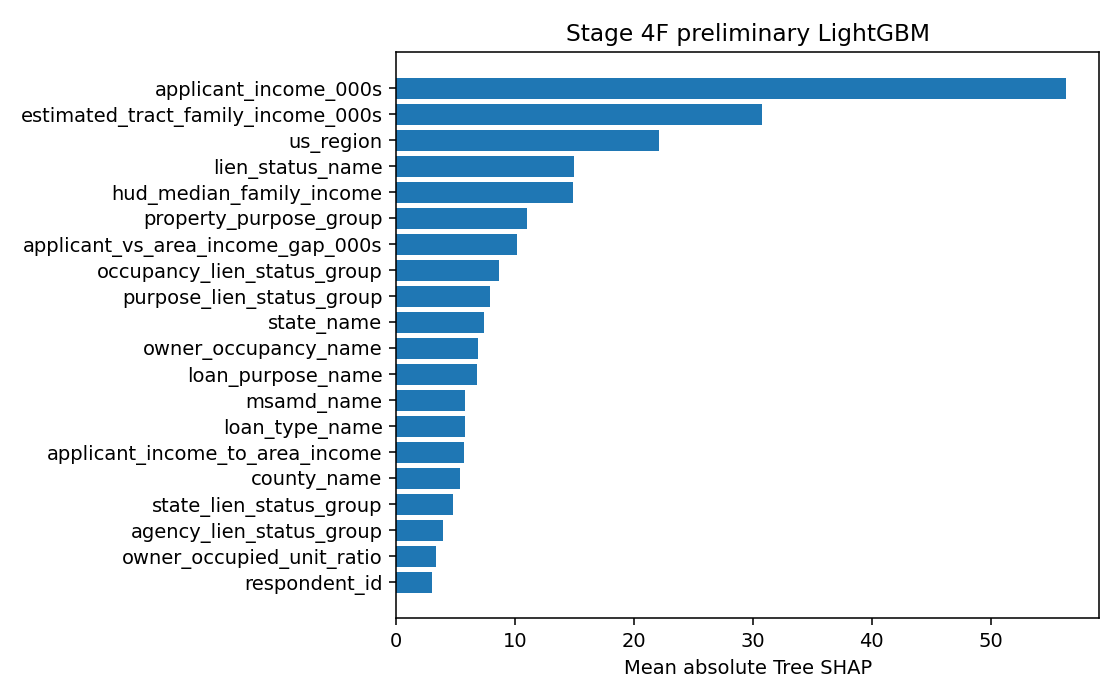

In [15]:
show_csv('artifacts/features/stage4/lightgbm/stage4f_shap_top20.csv', ['source_feature','mean_absolute_shap'], 10)
display(Image(filename=str(ROOT / 'artifacts/figures/stage4/lightgbm/stage4f_shap_summary.png')))

### 15. Error Analysis

Reason: This section checks the saved evidence for Error Analysis.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The extreme target tail remains the hardest region.

In [16]:
show_csv('artifacts/results/stage4/lightgbm/initial/stage4f_error_by_target_decile.csv', None, 10)
show_json('artifacts/results/stage4/lightgbm/initial/stage4f_error_summary.json')

,target_decile,rows,mae,mean_signed_error,underestimation_rate,overestimation_rate
0,1,1502,31.155278,24.411229,0.278961,0.721039
1,2,1517,43.474814,36.139638,0.199077,0.800923
2,3,1493,41.402619,27.056241,0.335566,0.664434
3,4,1515,39.489238,19.591935,0.411881,0.588119
4,5,1485,39.212441,9.788914,0.477441,0.522559
5,6,1491,47.498839,6.750380,0.539235,0.460765
6,7,1503,51.647818,-8.984547,0.622754,0.377246
7,8,1513,65.181295,-18.948825,0.656312,0.343688
8,9,1483,84.116830,-36.850778,0.700607,0.299393
9,10,1498,203.364352,-157.008357,0.817757,0.182243


{'top_decile_mae': 202.70000253059425,
 'top_five_percent_mae': 292.84345809387196,
 'underestimation_rate': 0.5034666666666666,
 'overestimation_rate': 0.4965333333333333,
 'worst_decile_by_mae': 10,
 'status': 'PASS'}

{'top_decile_mae': 202.70000253059425,
 'top_five_percent_mae': 292.84345809387196,
 'underestimation_rate': 0.5034666666666666,
 'overestimation_rate': 0.4965333333333333,
 'worst_decile_by_mae': 10,
 'status': 'PASS'}

### 16. Stage 4G Feature Proposals

Reason: This section checks the saved evidence for Stage 4G Feature Proposals.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Three safe proposals moved to independent confirmation.

In [17]:
show_csv('artifacts/features/stage4/lightgbm/stage4f_feature_proposals.csv', ['name','expected_benefit','target_derived','sensitive_derived','leakage_review'], 3)

,name,expected_benefit,target_derived,sensitive_derived,leakage_review
0,applicant_to_estimated_tract_income_ratio,Adds a direct applicant-versus-local-income sc...,False,False,PASS: uses current-row non-sensitive predictor...
1,respondent_purpose_group,Lets the model distinguish lender-purpose conc...,False,False,PASS: frequency mapping fits on training rows ...
2,income_band_lien_status_group,Adds a compact nonlinear interaction that may ...,False,False,PASS: quantiles fit on non-sensitive training ...


,name,formula,source_columns,evidence,expected_benefit,fixed_or_learned,missing_handling,zero_denominator_handling,target_derived,sensitive_derived,leakage_review,duplicate_review
0,applicant_to_estimated_tract_income_ratio,applicant_income_000s / max(abs(estimated_trac...,applicant_income_000s|hud_median_family_income...,Income and area-income signals appear in gain/...,Adds a direct applicant-versus-local-income sc...,fixed safe ratio; epsilon is fixed,Missing or non-finite source gives missing for...,Use epsilon only for finite near-zero denomina...,False,False,PASS: uses current-row non-sensitive predictor...,PASS: not present in Stage 4B packs; not an ex...
1,respondent_purpose_group,"respondent_id + ' | ' + loan_purpose_name, the...",respondent_id|loan_purpose_name,High-cardinality frequency and loan-purpose ev...,Lets the model distinguish lender-purpose conc...,fixed interaction plus training-fit frequency ...,Missing parts use <MISSING>; unseen Validation...,Not applicable.,False,False,PASS: frequency mapping fits on training rows ...,PASS: the pair is absent from Stage 4B packs.
2,income_band_lien_status_group,training-fit applicant-income quantile band + ...,applicant_income_000s|lien_status_name,Income/lien structure is important and signed ...,Adds a compact nonlinear interaction that may ...,training-fit income quantiles inside Pipeline ...,Missing income or lien uses <MISSING>; unseen ...,Not applicable.,False,False,PASS: quantiles fit on non-sensitive training ...,PASS: the pair is absent from Stage 4B packs.


### 17. Stage 4F Gate Summary

Reason: This section checks the saved evidence for Stage 4F Gate Summary.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Stage 4F Gate reports PASS.

In [18]:
show_json('artifacts/reports/stage4f_gate_verification.json', ['candidate_count','optional_refinement_count','selected_candidate','checks','status'])

{'candidate_count': 4,
 'optional_refinement_count': 1,
 'selected_candidate': 'candidate_02_encoded_raw',
 'checks': {'discovery_sample_valid': True,
  'zero_test_overlap': True,
  'three_required_candidates_complete': True,
  'candidate_count_at_most_four': True,
  'raw_and_log_targets_evaluated': True,
  'preliminary_configuration_frozen': True,
  'preliminary_model_saved': True,
  'clean_reload_pass': True,
  'gain_importance_exists': True,
  'split_importance_exists': True,
  'bounded_shap_exists': True,
  'error_analysis_exists': True,
  'safe_feature_proposals_at_most_three': True,
  'registry_ids_unique': True,
  'prior_registry_rows_preserved': True,
  'protected_hashes_unchanged': True},
 'status': 'PASS'}

{'stage_id': 'stage4f',
 'stage_name': 'Stage 4F — Initial LightGBM Model and Importance Analysis',
 'created_at_utc': '2026-07-14T17:51:00.372621+00:00',
 'candidate_count': 4,
 'required_candidate_count': 3,
 'optional_refinement_count': 1,
 'selected_candidate': 'candidate_02_encoded_raw',
 'checks': {'discovery_sample_valid': True,
  'zero_test_overlap': True,
  'three_required_candidates_complete': True,
  'candidate_count_at_most_four': True,
  'raw_and_log_targets_evaluated': True,
  'preliminary_configuration_frozen': True,
  'preliminary_model_saved': True,
  'clean_reload_pass': True,
  'gain_importance_exists': True,
  'split_importance_exists': True,
  'bounded_shap_exists': True,
  'error_analysis_exists': True,
  'safe_feature_proposals_at_most_three': True,
  'registry_ids_unique': True,
  'prior_registry_rows_preserved': True,
  'protected_hashes_unchanged': True},
 'status': 'PASS',
 'runtime_seconds': 8.785763300009421}

## Stage 4G — Feature Confirmation and Final Tuning

### 18. Stage 4G Objective

Reason: Stage 4G uses independent non-sensitive samples for Feature confirmation and tuning.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Stage 4G keeps all selection non-sensitive.

In [19]:
print({'selection_mode': 'without_sensitive', 'confirmation_rows': '80000/20000', 'tuning_rows': '100000/25000', 'test_rows': 0})

{'selection_mode': 'without_sensitive', 'confirmation_rows': '80000/20000', 'tuning_rows': '100000/25000', 'test_rows': 0}


### 19. Stage 4F Gate Validation

Reason: This section checks the saved evidence for Stage 4F Gate Validation.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Stage 4G started only after Stage 4F PASS.

In [20]:
show_json('artifacts/reports/stage4f_gate_verification.json', ['status'])

{'status': 'PASS'}

{'stage_id': 'stage4f',
 'stage_name': 'Stage 4F — Initial LightGBM Model and Importance Analysis',
 'created_at_utc': '2026-07-14T17:51:00.372621+00:00',
 'candidate_count': 4,
 'required_candidate_count': 3,
 'optional_refinement_count': 1,
 'selected_candidate': 'candidate_02_encoded_raw',
 'checks': {'discovery_sample_valid': True,
  'zero_test_overlap': True,
  'three_required_candidates_complete': True,
  'candidate_count_at_most_four': True,
  'raw_and_log_targets_evaluated': True,
  'preliminary_configuration_frozen': True,
  'preliminary_model_saved': True,
  'clean_reload_pass': True,
  'gain_importance_exists': True,
  'split_importance_exists': True,
  'bounded_shap_exists': True,
  'error_analysis_exists': True,
  'safe_feature_proposals_at_most_three': True,
  'registry_ids_unique': True,
  'prior_registry_rows_preserved': True,
  'protected_hashes_unchanged': True},
 'status': 'PASS',
 'runtime_seconds': 8.785763300009421}

### 20. Feature Proposal Review

Reason: This section checks the saved evidence for Feature Proposal Review.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: All proposals passed safety review before testing.

In [21]:
show_csv('artifacts/features/stage4/lightgbm/stage4g_proposal_review.csv', ['name','formula_valid','target_independent','sensitive_independent','approved_for_confirmation','final_status'], 3)

,name,formula_valid,target_independent,sensitive_independent,approved_for_confirmation,final_status
0,applicant_to_estimated_tract_income_ratio,True,True,True,True,REJECTED_BY_INDEPENDENT_CONFIRMATION
1,respondent_purpose_group,True,True,True,True,REJECTED_BY_INDEPENDENT_CONFIRMATION
2,income_band_lien_status_group,True,True,True,True,REJECTED_BY_INDEPENDENT_CONFIRMATION


,name,formula,source_columns,evidence,expected_benefit,fixed_or_learned,missing_handling,zero_denominator_handling,target_derived,sensitive_derived,leakage_review,duplicate_review,formula_valid,sources_available,target_independent,sensitive_independent,approved_for_confirmation,accepted_after_confirmation,final_status
0,applicant_to_estimated_tract_income_ratio,applicant_income_000s / max(abs(estimated_trac...,applicant_income_000s|hud_median_family_income...,Income and area-income signals appear in gain/...,Adds a direct applicant-versus-local-income sc...,fixed safe ratio; epsilon is fixed,Missing or non-finite source gives missing for...,Use epsilon only for finite near-zero denomina...,False,False,PASS: uses current-row non-sensitive predictor...,PASS: not present in Stage 4B packs; not an ex...,True,True,True,True,True,False,REJECTED_BY_INDEPENDENT_CONFIRMATION
1,respondent_purpose_group,"respondent_id + ' | ' + loan_purpose_name, the...",respondent_id|loan_purpose_name,High-cardinality frequency and loan-purpose ev...,Lets the model distinguish lender-purpose conc...,fixed interaction plus training-fit frequency ...,Missing parts use <MISSING>; unseen Validation...,Not applicable.,False,False,PASS: frequency mapping fits on training rows ...,PASS: the pair is absent from Stage 4B packs.,True,True,True,True,True,False,REJECTED_BY_INDEPENDENT_CONFIRMATION
2,income_band_lien_status_group,training-fit applicant-income quantile band + ...,applicant_income_000s|lien_status_name,Income/lien structure is important and signed ...,Adds a compact nonlinear interaction that may ...,training-fit income quantiles inside Pipeline ...,Missing income or lien uses <MISSING>; unseen ...,Not applicable.,False,False,PASS: quantiles fit on non-sensitive training ...,PASS: the pair is absent from Stage 4B packs.,True,True,True,True,True,False,REJECTED_BY_INDEPENDENT_CONFIRMATION


### 21. LightGBM Feature Engineer v2

Reason: This section checks the saved evidence for LightGBM Feature Engineer v2.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Feature Engineer v2 is serializable and does not mutate inputs.

In [22]:
show_json('artifacts/reports/stage4g_feature_engineer_v2_roundtrip.json', ['feature_engineer_version','fit_rows','check_rows','source_unchanged','row_order_preserved','stable_columns','joblib_reload','status'])

{'feature_engineer_version': 'lightgbm_feature_engineer_v2_20260714',
 'fit_rows': 200,
 'check_rows': 50,
 'source_unchanged': True,
 'row_order_preserved': True,
 'stable_columns': True,
 'joblib_reload': True,
 'status': 'PASS'}

{'stage_id': 'stage4g',
 'feature_engineer_version': 'lightgbm_feature_engineer_v2_20260714',
 'selected_proposals': ['applicant_to_estimated_tract_income_ratio',
  'respondent_purpose_group',
  'income_band_lien_status_group'],
 'fit_rows': 200,
 'check_rows': 50,
 'source_unchanged': True,
 'row_order_preserved': True,
 'stable_columns': True,
 'joblib_reload': True,
 'clean_process_return_code': 0,
 'clean_process_stdout': 'PASS 50 39\n',
 'clean_process_stderr': '',
 'target_used': False,
 'sensitive_sources_used': False,
 'status': 'PASS'}

### 22. Feature Confirmation Sample

Reason: This section checks the saved evidence for Feature Confirmation Sample.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The independent 80,000/20,000 roles were used.

In [23]:
display(sample_check['samples']['feature_confirmation'])

{'rows': 100000,
 'train_rows': 80000,
 'validation_rows': 20000,
 'expected_rows': 100000,
 'row_ids_unique': True,
 'maximum_target_bin_proportion_difference': 1.2069997098462792e-05,
 'role_maximum_target_bin_proportion_difference': {'train': 7.06999709847167e-06,
  'validation': 3.2069997098468916e-05},
 'sha256': '2dabbdc5e6b0fee9bc50e63feeb912e3096a5408cafbbf1685c1e00332380cf4',
 'valid': True}

### 23. Lean Feature Confirmation

Reason: This section checks the saved evidence for Lean Feature Confirmation.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Neither combined nor ratio-only v2 met acceptance rules.

In [24]:
show_csv('artifacts/results/stage4/lightgbm/feature_confirmation/lightgbm_feature_confirmation_results.csv', None, 3)

,fit_id,feature_pack,selected_proposals,mae,mae_change_percent_vs_original,rmse,rmse_change_percent_vs_original,top_decile_mae,top_decile_change_percent_vs_original,p90_absolute_error,mean_signed_error,fit_time_seconds,best_iteration
0,confirmation_original,lightgbm_encoded_v1,NaN,65.216082,0.000000,136.944704,0.000000,206.705861,0.000000,137.717701,-8.365230,10.883856,1500
1,confirmation_combined_v2,lightgbm_encoded_v2_combined,applicant_to_estimated_tract_income_ratio|resp...,65.085851,-0.199693,137.362228,0.304885,206.496610,-0.101231,138.757580,-8.600328,11.153973,1499
2,confirmation_ratio_rescue_v2,lightgbm_encoded_v2_ratio,applicant_to_estimated_tract_income_ratio,65.131164,-0.130211,136.855877,-0.064863,206.368943,-0.162994,138.477112,-8.454009,10.546426,1483


,fit_id,feature_pack,selected_proposals,mae,mae_change_percent_vs_original,rmse,rmse_change_percent_vs_original,top_decile_mae,top_decile_change_percent_vs_original,p90_absolute_error,mean_signed_error,fit_time_seconds,best_iteration
0,confirmation_original,lightgbm_encoded_v1,NaN,65.216082,0.000000,136.944704,0.000000,206.705861,0.000000,137.717701,-8.365230,10.883856,1500
1,confirmation_combined_v2,lightgbm_encoded_v2_combined,applicant_to_estimated_tract_income_ratio|resp...,65.085851,-0.199693,137.362228,0.304885,206.496610,-0.101231,138.757580,-8.600328,11.153973,1499
2,confirmation_ratio_rescue_v2,lightgbm_encoded_v2_ratio,applicant_to_estimated_tract_income_ratio,65.131164,-0.130211,136.855877,-0.064863,206.368943,-0.162994,138.477112,-8.454009,10.546426,1483


### 24. Final Feature Pack

Reason: This section checks the saved evidence for Final Feature Pack.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The original encoded pack remained final.

In [25]:
show_json('artifacts/results/stage4/lightgbm/feature_confirmation/lightgbm_final_feature_pack.json', ['accepted_features','rejected_features','final_feature_pack','reason','status'])

{'accepted_features': [],
 'rejected_features': ['applicant_to_estimated_tract_income_ratio',
  'respondent_purpose_group',
  'income_band_lien_status_group'],
 'final_feature_pack': 'lightgbm_encoded_v1',
 'reason': 'Combined v2 improved MAE by only 0.200% and worsened RMSE, P90 error, and signed bias. The ratio-only rescue improved MAE by only 0.130% and tail MAE by only 0.163%, while P90 and signed bias worsened. Neither met the main, tail, or stability rule.',
 'status': 'PASS'}

{'stage_id': 'stage4g',
 'original_feature_pack': 'lightgbm_encoded_v1',
 'combined_feature_pack': 'lightgbm_encoded_v2_combined',
 'optional_rescue_feature_pack': 'lightgbm_encoded_v2_ratio',
 'accepted_features': [],
 'rejected_features': ['applicant_to_estimated_tract_income_ratio',
  'respondent_purpose_group',
  'income_band_lien_status_group'],
 'final_feature_pack': 'lightgbm_encoded_v1',
 'selected_proposals': [],
 'reason': 'Combined v2 improved MAE by only 0.200% and worsened RMSE, P90 error, and signed bias. The ratio-only rescue improved MAE by only 0.130% and tail MAE by only 0.163%, while P90 and signed bias worsened. Neither met the main, tail, or stability rule.',
 'acceptance_rules': {'main_mae_improvement_percent': 0.5,
  'tail_improvement_percent': 2.0,
  'maximum_overall_worsening_percent': 0.2},
 'fit_count': 3,
 'sensitive_mode': 'without_sensitive',
 'test_rows': 0,
 'status': 'PASS'}

### 25. Final Selection Sample

Reason: This section checks the saved evidence for Final Selection Sample.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The independent 100,000/25,000 roles were used.

In [26]:
display(sample_check['samples']['final_selection'])

{'rows': 125000,
 'train_rows': 100000,
 'validation_rows': 25000,
 'expected_rows': 125000,
 'row_ids_unique': True,
 'maximum_target_bin_proportion_difference': 7.974866679333337e-06,
 'role_maximum_target_bin_proportion_difference': {'train': 5.974866679345214e-06,
  'validation': 1.5974866679341337e-05},
 'sha256': '445a077b3fc1963bec38d8ba90384df2e1400e3897b25f0ecbfce78cb96c49ef',
 'valid': True}

### 26. Three Final Tuning Candidates

Reason: This section checks the saved evidence for Three Final Tuning Candidates.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Exactly three tuning Candidates completed.

In [27]:
show_csv('artifacts/results/stage4/lightgbm/final/lightgbm_final_tuning_results.csv', ['candidate_id','num_leaves','min_child_samples','reg_lambda','mae','rmse','top_decile_mae','best_iteration'], 3)

,candidate_id,num_leaves,min_child_samples,reg_lambda,mae,rmse,top_decile_mae,best_iteration
0,tuning_a_baseline,31,50,5.0,64.783622,133.257522,204.055699,1500
1,tuning_b_safer,23,80,10.0,64.964520,134.262362,204.946252,1499
2,tuning_c_flexible,47,50,5.0,64.456751,131.956170,203.032071,1500


,candidate_id,num_leaves,min_child_samples,reg_lambda,best_iteration,fit_time_seconds,mae,mse,rmse,mape_percent,...,p90_absolute_error,negative_prediction_rate,mae_usd,rmse_usd,original_scale,top_decile_mae,top_five_percent_mae,underestimation_rate,overestimation_rate,mae_rank
0,tuning_a_baseline,31,50,5.0,1500,12.596510,64.783622,17757.567082,133.257522,38.712147,...,137.477174,0.00492,64783.622151,133257.521670,True,204.055699,299.120778,0.49968,0.50032,2
1,tuning_b_safer,23,80,10.0,1499,11.574149,64.964520,18026.381732,134.262362,38.677460,...,137.270940,0.00544,64964.519972,134262.361563,True,204.946252,300.720083,0.50000,0.50000,3
2,tuning_c_flexible,47,50,5.0,1500,14.205618,64.456751,17412.430780,131.956170,38.233347,...,137.075353,0.00456,64456.751122,131956.169919,True,203.032071,297.460231,0.49732,0.50268,1


### 27. Final Non-Sensitive Configuration

Reason: This section checks the saved evidence for Final Non-Sensitive Configuration.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Candidate C froze 47 leaves and 1,500 iterations.

In [28]:
show_json('artifacts/results/stage4/lightgbm/final/lightgbm_final_configuration.json', ['selected_candidate','selection_reason','feature_pack','target_mode','parameters','fixed_iteration','thread_count','status'])

{'selected_candidate': 'tuning_c_flexible',
 'selection_reason': 'Candidate C had the lowest MAE, tail MAE, RMSE, clipped-zero RMSLE, and better signed error than the baseline; the MAE gain exceeded the 0.25 percent tie band.',
 'feature_pack': 'lightgbm_encoded_v1',
 'target_mode': 'raw',
 'parameters': {'n_estimators': 1500,
  'learning_rate': 0.05,
  'num_leaves': 47,
  'max_depth': -1,
  'min_child_samples': 50,
  'subsample': 0.8,
  'subsample_freq': 1,
  'colsample_bytree': 0.8,
  'reg_alpha': 0.0,
  'reg_lambda': 5.0,
  'random_state': 42,
  'n_jobs': 2,
  'objective': 'regression_l1',
  'verbosity': -1},
 'fixed_iteration': 1500,
 'thread_count': 2,
 'status': 'FROZEN'}

{'stage_id': 'stage4g',
 'stage_name': 'Stage 4G — LightGBM Feature Confirmation and Final Tuning',
 'selected_candidate': 'tuning_c_flexible',
 'selection_reason': 'Candidate C had the lowest MAE, tail MAE, RMSE, clipped-zero RMSLE, and better signed error than the baseline; the MAE gain exceeded the 0.25 percent tie band.',
 'feature_pack': 'lightgbm_encoded_v1',
 'selected_proposals': [],
 'accepted_features': [],
 'rejected_features': ['applicant_to_estimated_tract_income_ratio',
  'respondent_purpose_group',
  'income_band_lien_status_group'],
 'target_mode': 'raw',
 'parameters': {'n_estimators': 1500,
  'learning_rate': 0.05,
  'num_leaves': 47,
  'max_depth': -1,
  'min_child_samples': 50,
  'subsample': 0.8,
  'subsample_freq': 1,
  'colsample_bytree': 0.8,
  'reg_alpha': 0.0,
  'reg_lambda': 5.0,
  'random_state': 42,
  'n_jobs': 2,
  'objective': 'regression_l1',
  'verbosity': -1},
 'fixed_iteration': 1500,
 'random_seed': 42,
 'thread_count': 2,
 'encoding_policy': 'traini

### 28. Winning Non-Sensitive Validation Model

Reason: This section checks the saved evidence for Winning Non-Sensitive Validation Model.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The winning non-sensitive model is saved for reuse.

In [29]:
show_json('artifacts/manifests/stage4/lightgbm/stage4g_winning_non_sensitive_manifest.json', ['experiment_id','model_path','native_model_path','prediction_path','metrics','reuse_required_in_stage4h','status'])

{'experiment_id': 'stage4g__final_tuning__candidate_c_flexible',
 'model_path': 'artifacts\\models\\lightgbm\\final\\lightgbm_final_selection_without_sensitive.joblib',
 'native_model_path': 'artifacts\\models\\lightgbm\\final\\lightgbm_final_selection_without_sensitive.txt',
 'prediction_path': 'artifacts\\predictions\\lightgbm\\final\\lightgbm_final_selection_without_sensitive.csv',
 'metrics': {'mae': 64.45675112229286,
  'mse': 17412.430779767787,
  'rmse': 131.95616991928716,
  'mape_percent': 38.233346757275214,
  'r_squared': 0.6856598010936056,
  'rmsle': None,
  'rmsle_clipped_zero': 0.44555123751585085,
  'median_absolute_error': 37.863387791917035,
  'wape_percent': 26.1100156045356,
  'mean_signed_error': -8.54457832711679,
  'p90_absolute_error': 137.07535259409207,
  'negative_prediction_rate': 0.00456,
  'mae_usd': 64456.75112229286,
  'rmse_usd': 131956.16991928717,
  'original_scale': True,
  'top_decile_mae': 203.03207088207972,
  'top_five_percent_mae': 297.460231207

{'stage_id': 'stage4g',
 'experiment_id': 'stage4g__final_tuning__candidate_c_flexible',
 'selected_candidate': 'tuning_c_flexible',
 'model_path': 'artifacts\\models\\lightgbm\\final\\lightgbm_final_selection_without_sensitive.joblib',
 'native_model_path': 'artifacts\\models\\lightgbm\\final\\lightgbm_final_selection_without_sensitive.txt',
 'prediction_path': 'artifacts\\predictions\\lightgbm\\final\\lightgbm_final_selection_without_sensitive.csv',
 'model_sha256': 'bc2ed4187bdad9fed21ee40491153a836f997d192dfbd69314d7122343e01ec8',
 'native_model_sha256': '73bf9635f4dac253454e06d42ed5376ddb08266fe4546165ee059da9c4c51e22',
 'prediction_sha256': '3b48e7ed45ad1c7c4f5f947833b0de251758d8f1b39c59c4a049152f7815407a',
 'metrics': {'mae': 64.45675112229286,
  'mse': 17412.430779767787,
  'rmse': 131.95616991928716,
  'mape_percent': 38.233346757275214,
  'r_squared': 0.6856598010936056,
  'rmsle': None,
  'rmsle_clipped_zero': 0.44555123751585085,
  'median_absolute_error': 37.86338779191703

### 29. Clean Reload

Reason: This section checks the saved evidence for Clean Reload.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The winning model reloads and prediction-matches.

In [30]:
show_json('artifacts/reports/stage4g_winning_model_reload.json', ['rows','reference_prediction_match','native_prediction_match','source_frame_unchanged','status'])

{'rows': 500,
 'reference_prediction_match': True,
 'native_prediction_match': True,
 'source_frame_unchanged': True,
 'status': 'PASS'}

### 30. Stage 4G Gate Summary

Reason: This section checks the saved evidence for Stage 4G Gate Summary.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Stage 4G Gate reports PASS.

In [31]:
show_json('artifacts/reports/stage4g_gate_verification.json', ['feature_confirmation_fit_count','tuning_candidate_count','selected_candidate','final_feature_pack','fixed_iteration','checks','status'])

{'feature_confirmation_fit_count': 3,
 'tuning_candidate_count': 3,
 'selected_candidate': 'tuning_c_flexible',
 'final_feature_pack': 'lightgbm_encoded_v1',
 'fixed_iteration': 1500,
 'checks': {'stage4f_gate_pass': True,
  'feature_confirmation_sample_valid': True,
  'final_selection_sample_valid': True,
  'no_test_rows_used': True,
  'proposal_count_at_most_three': True,
  'feature_confirmation_fit_count_at_most_three': True,
  'feature_engineer_v2_serializable': True,
  'final_feature_pack_frozen': True,
  'exactly_three_tuning_candidates_complete': True,
  'tuning_non_sensitive_only': True,
  'final_configuration_frozen': True,
  'winning_non_sensitive_model_saved': True,
  'validation_predictions_complete': True,
  'winning_model_reload_pass': True,
  'registry_ids_unique': True,
  'protected_hashes_unchanged': True},
 'status': 'PASS'}

{'stage_id': 'stage4g',
 'stage_name': 'Stage 4G — LightGBM Feature Confirmation and Final Tuning',
 'created_at_utc': '2026-07-14T17:56:50.844102+00:00',
 'feature_confirmation_fit_count': 3,
 'tuning_candidate_count': 3,
 'selected_candidate': 'tuning_c_flexible',
 'final_feature_pack': 'lightgbm_encoded_v1',
 'fixed_iteration': 1500,
 'checks': {'stage4f_gate_pass': True,
  'feature_confirmation_sample_valid': True,
  'final_selection_sample_valid': True,
  'no_test_rows_used': True,
  'proposal_count_at_most_three': True,
  'feature_confirmation_fit_count_at_most_three': True,
  'feature_engineer_v2_serializable': True,
  'final_feature_pack_frozen': True,
  'exactly_three_tuning_candidates_complete': True,
  'tuning_non_sensitive_only': True,
  'final_configuration_frozen': True,
  'winning_non_sensitive_model_saved': True,
  'validation_predictions_complete': True,
  'winning_model_reload_pass': True,
  'registry_ids_unique': True,
  'protected_hashes_unchanged': True},
 'status'

## Stage 4H — Sensitive Comparison and Full-Train Models

### 31. Stage 4H Objective

Reason: Stage 4H reuses the non-sensitive winner, compares one sensitive model, and saves two full-Train bundles.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Stage 4H uses one frozen comparison and two final fits.

In [32]:
print({'non_sensitive_action': 'reuse', 'new_sensitive_validation_fits': 1, 'full_train_fits': 2, 'test_rows': 0})

{'non_sensitive_action': 'reuse', 'new_sensitive_validation_fits': 1, 'full_train_fits': 2, 'test_rows': 0}


### 32. Stage 4G Gate Validation

Reason: This section checks the saved evidence for Stage 4G Gate Validation.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Stage 4H started only after Stage 4G PASS.

In [33]:
show_json('artifacts/reports/stage4g_gate_verification.json', ['status'])

{'status': 'PASS'}

{'stage_id': 'stage4g',
 'stage_name': 'Stage 4G — LightGBM Feature Confirmation and Final Tuning',
 'created_at_utc': '2026-07-14T17:56:50.844102+00:00',
 'feature_confirmation_fit_count': 3,
 'tuning_candidate_count': 3,
 'selected_candidate': 'tuning_c_flexible',
 'final_feature_pack': 'lightgbm_encoded_v1',
 'fixed_iteration': 1500,
 'checks': {'stage4f_gate_pass': True,
  'feature_confirmation_sample_valid': True,
  'final_selection_sample_valid': True,
  'no_test_rows_used': True,
  'proposal_count_at_most_three': True,
  'feature_confirmation_fit_count_at_most_three': True,
  'feature_engineer_v2_serializable': True,
  'final_feature_pack_frozen': True,
  'exactly_three_tuning_candidates_complete': True,
  'tuning_non_sensitive_only': True,
  'final_configuration_frozen': True,
  'winning_non_sensitive_model_saved': True,
  'validation_predictions_complete': True,
  'winning_model_reload_pass': True,
  'registry_ids_unique': True,
  'protected_hashes_unchanged': True},
 'status'

### 33. Frozen Final Configuration

Reason: This section checks the saved evidence for Frozen Final Configuration.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The same frozen configuration is used in both modes.

In [34]:
show_json('artifacts/results/stage4/lightgbm/final/lightgbm_final_configuration.json', ['feature_pack','selected_proposals','target_mode','parameters','fixed_iteration','random_seed','thread_count'])

{'feature_pack': 'lightgbm_encoded_v1',
 'selected_proposals': [],
 'target_mode': 'raw',
 'parameters': {'n_estimators': 1500,
  'learning_rate': 0.05,
  'num_leaves': 47,
  'max_depth': -1,
  'min_child_samples': 50,
  'subsample': 0.8,
  'subsample_freq': 1,
  'colsample_bytree': 0.8,
  'reg_alpha': 0.0,
  'reg_lambda': 5.0,
  'random_state': 42,
  'n_jobs': 2,
  'objective': 'regression_l1',
  'verbosity': -1},
 'fixed_iteration': 1500,
 'random_seed': 42,
 'thread_count': 2}

{'stage_id': 'stage4g',
 'stage_name': 'Stage 4G — LightGBM Feature Confirmation and Final Tuning',
 'selected_candidate': 'tuning_c_flexible',
 'selection_reason': 'Candidate C had the lowest MAE, tail MAE, RMSE, clipped-zero RMSLE, and better signed error than the baseline; the MAE gain exceeded the 0.25 percent tie band.',
 'feature_pack': 'lightgbm_encoded_v1',
 'selected_proposals': [],
 'accepted_features': [],
 'rejected_features': ['applicant_to_estimated_tract_income_ratio',
  'respondent_purpose_group',
  'income_band_lien_status_group'],
 'target_mode': 'raw',
 'parameters': {'n_estimators': 1500,
  'learning_rate': 0.05,
  'num_leaves': 47,
  'max_depth': -1,
  'min_child_samples': 50,
  'subsample': 0.8,
  'subsample_freq': 1,
  'colsample_bytree': 0.8,
  'reg_alpha': 0.0,
  'reg_lambda': 5.0,
  'random_state': 42,
  'n_jobs': 2,
  'objective': 'regression_l1',
  'verbosity': -1},
 'fixed_iteration': 1500,
 'random_seed': 42,
 'thread_count': 2,
 'encoding_policy': 'traini

### 34. Reused Non-Sensitive Validation Result

Reason: This section checks the saved evidence for Reused Non-Sensitive Validation Result.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The non-sensitive Validation model was reused without refitting.

In [35]:
show_json('artifacts/reports/stage4h_non_sensitive_reuse_verification.json', ['reused_stage4g_experiment_id','metrics','checks','status'])

{'reused_stage4g_experiment_id': 'stage4g__final_tuning__candidate_c_flexible',
 'metrics': {'mae': 64.45675112229286,
  'mse': 17412.430779767787,
  'rmse': 131.95616991928716,
  'mape_percent': 38.233346757275214,
  'r_squared': 0.6856598010936056,
  'rmsle': None,
  'rmsle_clipped_zero': 0.44555123751585085,
  'median_absolute_error': 37.863387791917035,
  'wape_percent': 26.1100156045356,
  'mean_signed_error': -8.54457832711679,
  'p90_absolute_error': 137.07535259409207,
  'negative_prediction_rate': 0.00456,
  'mae_usd': 64456.75112229286,
  'rmse_usd': 131956.16991928717,
  'original_scale': True,
  'top_decile_mae': 203.03207088207972,
  'top_five_percent_mae': 297.4602312076121,
  'underestimation_rate': 0.49732,
  'overestimation_rate': 0.50268},
 'checks': {'stage4g_gate_pass': True,
  'model_hash_match': True,
  'native_hash_match': True,
  'prediction_hash_match': True,
  'validation_row_ids_match': True,
  'validation_rows_25000': True,
  'sensitive_mode_without': True,


{'stage_id': 'stage4h',
 'reused_stage4g_experiment_id': 'stage4g__final_tuning__candidate_c_flexible',
 'model_path': 'artifacts\\models\\lightgbm\\final\\lightgbm_final_selection_without_sensitive.joblib',
 'native_model_path': 'artifacts\\models\\lightgbm\\final\\lightgbm_final_selection_without_sensitive.txt',
 'prediction_path': 'artifacts\\predictions\\lightgbm\\final\\lightgbm_final_selection_without_sensitive.csv',
 'metrics': {'mae': 64.45675112229286,
  'mse': 17412.430779767787,
  'rmse': 131.95616991928716,
  'mape_percent': 38.233346757275214,
  'r_squared': 0.6856598010936056,
  'rmsle': None,
  'rmsle_clipped_zero': 0.44555123751585085,
  'median_absolute_error': 37.863387791917035,
  'wape_percent': 26.1100156045356,
  'mean_signed_error': -8.54457832711679,
  'p90_absolute_error': 137.07535259409207,
  'negative_prediction_rate': 0.00456,
  'mae_usd': 64456.75112229286,
  'rmse_usd': 131956.16991928717,
  'original_scale': True,
  'top_decile_mae': 203.03207088207972,


### 35. Single Sensitive Validation Fit

Reason: This section checks the saved evidence for Single Sensitive Validation Fit.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Exactly one sensitive Validation fit completed.

In [36]:
show_json('artifacts/checkpoints/stage4/lightgbm/sensitive_validation.json', ['experiment_id','training_row_count','validation_row_count','fixed_or_best_iteration','metrics','status'])

{'experiment_id': 'stage4h__final_selection_validation__with_sensitive',
 'training_row_count': 100000,
 'validation_row_count': 25000,
 'fixed_or_best_iteration': 1500,
 'metrics': {'mae': 64.33219557514754,
  'mse': 17546.94773126264,
  'rmse': 132.46489244800918,
  'mape_percent': 38.26158059241634,
  'r_squared': 0.6832314161182977,
  'rmsle': None,
  'rmsle_clipped_zero': 0.4480312510294626,
  'median_absolute_error': 37.823662304587,
  'wape_percent': 26.059560885317357,
  'mean_signed_error': -8.512014868239051,
  'p90_absolute_error': 136.50835971598585,
  'negative_prediction_rate': 0.00444,
  'mae_usd': 64332.19557514754,
  'rmse_usd': 132464.89244800917,
  'original_scale': True,
  'top_decile_mae': 202.72249327652963,
  'top_five_percent_mae': 296.48447349153815,
  'underestimation_rate': 0.49992,
  'overestimation_rate': 0.50008},
 'status': 'PASS'}

{'stage_id': 'stage4h',
 'stage_name': 'Stage 4H — Final LightGBM Sensitive Comparison and Full-Train Models',
 'experiment_id': 'stage4h__final_selection_validation__with_sensitive',
 'job_type': 'validation',
 'feature_pack': 'lightgbm_encoded_v1',
 'feature_engineer_version': 'stage4b_initial_boosting_packs_v1_20260714',
 'selected_proposals': [],
 'target_mode': 'raw',
 'sensitive_mode': 'with_sensitive',
 'parameters': {'n_estimators': 1500,
  'learning_rate': 0.05,
  'num_leaves': 47,
  'max_depth': -1,
  'min_child_samples': 50,
  'subsample': 0.8,
  'subsample_freq': 1,
  'colsample_bytree': 0.8,
  'reg_alpha': 0.0,
  'reg_lambda': 5.0,
  'random_state': 42,
  'n_jobs': 2,
  'objective': 'regression_l1',
  'verbosity': -1},
 'fixed_or_best_iteration': 1500,
 'random_seed': 42,
 'thread_count': 2,
 'sample_name': 'final_selection',
 'sample_digest': '445a077b3fc1963bec38d8ba90384df2e1400e3897b25f0ecbfce78cb96c49ef',
 'feature_pack_digest': 'd19338809beb7afdd3df1e804c8d83cf45f86e

### 36. Controlled Sensitive Comparison

Reason: This section checks the saved evidence for Controlled Sensitive Comparison.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Sensitive differences are accuracy evidence, not a fairness result.

In [37]:
show_csv('artifacts/results/stage4/lightgbm/final/lightgbm_sensitive_validation_comparison.csv', None, 2)
show_json('artifacts/results/stage4/lightgbm/final/lightgbm_sensitive_validation_differences.json', ['difference_definition','not_test_evaluation','not_complete_fairness_result','differences','status'])

,evaluation_design,sensitive_mode,mae,mse,rmse,mape_percent,r_squared,rmsle,rmsle_clipped_zero,median_absolute_error,wape_percent,mean_signed_error,p90_absolute_error,negative_prediction_rate,top_decile_mae,top_five_percent_mae,fit_time_seconds,prediction_time_seconds,reused
0,Final Selection Validation,without_sensitive,64.456751,17412.430780,131.956170,38.233347,0.685660,NaN,0.445551,37.863388,26.110016,-8.544578,137.075353,0.00456,203.032071,297.460231,0.000000,0.000000,True
1,Final Selection Validation,with_sensitive,64.332196,17546.947731,132.464892,38.261581,0.683231,NaN,0.448031,37.823662,26.059561,-8.512015,136.508360,0.00444,202.722493,296.484473,15.309392,2.366741,False


{'difference_definition': 'with_sensitive - without_sensitive',
 'not_test_evaluation': True,
 'not_complete_fairness_result': True,
 'differences': {'mae': -0.12455554714532013,
  'mse': 134.51695149485386,
  'rmse': 0.5087225287220178,
  'mape_percent': 0.028233835141122654,
  'r_squared': -0.00242838497530784,
  'rmsle': None,
  'rmsle_clipped_zero': 0.0024800135136117674,
  'median_absolute_error': -0.03972548733003123,
  'wape_percent': -0.05045471921824429,
  'mean_signed_error': 0.03256345887773904,
  'p90_absolute_error': -0.5669928781062197,
  'negative_prediction_rate': -0.00011999999999999945,
  'top_decile_mae': -0.3095776055500892,
  'top_five_percent_mae': -0.9757577160739288},
 'status': 'PASS'}

{'stage_id': 'stage4h',
 'evaluation_design': 'Final Selection Validation',
 'difference_definition': 'with_sensitive - without_sensitive',
 'not_test_evaluation': True,
 'not_complete_fairness_result': True,
 'without_sensitive_experiment_id': 'stage4g__final_tuning__candidate_c_flexible',
 'without_sensitive_reused': True,
 'with_sensitive_experiment_id': 'stage4h__final_selection_validation__with_sensitive',
 'same_train_and_validation_rows': True,
 'same_feature_pack': True,
 'same_target_mode': True,
 'same_parameters': True,
 'same_fixed_iteration': True,
 'same_seed': True,
 'same_thread_count': True,
 'differences': {'mae': -0.12455554714532013,
  'mse': 134.51695149485386,
  'rmse': 0.5087225287220178,
  'mape_percent': 0.028233835141122654,
  'r_squared': -0.00242838497530784,
  'rmsle': None,
  'rmsle_clipped_zero': 0.0024800135136117674,
  'median_absolute_error': -0.03972548733003123,
  'wape_percent': -0.05045471921824429,
  'mean_signed_error': 0.03256345887773904,
  'p9

### 37. Full-Training Models

Reason: This section checks the saved evidence for Full-Training Models.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Both final models used all 399,788 Train rows and zero Test rows.

In [38]:
display(pd.DataFrame([show_json(f'artifacts/checkpoints/stage4/lightgbm/full_train_{mode}.json', ['sensitive_mode','training_row_count','test_row_count','fit_time_seconds','fixed_or_best_iteration','status']) for mode in ['without_sensitive','with_sensitive']]))

{'sensitive_mode': 'without_sensitive',
 'training_row_count': 399788,
 'test_row_count': 0,
 'fit_time_seconds': 55.55995150000672,
 'fixed_or_best_iteration': 1500,
 'status': 'PASS'}

{'sensitive_mode': 'with_sensitive',
 'training_row_count': 399788,
 'test_row_count': 0,
 'fit_time_seconds': 63.530905099993106,
 'fixed_or_best_iteration': 1500,
 'status': 'PASS'}

,stage_id,stage_name,experiment_id,job_type,feature_pack,feature_engineer_version,selected_proposals,target_mode,sensitive_mode,parameters,...,model_path,native_model_path,prediction_path,model_sha256,native_model_sha256,prediction_sha256,warnings,errors,status,created_at_utc
0,stage4h,Stage 4H — Final LightGBM Sensitive Comparison...,stage4h__full_train__without_sensitive,full_train,lightgbm_encoded_v1,stage4b_initial_boosting_packs_v1_20260714,[],raw,without_sensitive,"{'n_estimators': 1500, 'learning_rate': 0.05, ...",...,artifacts\models\lightgbm\final\lightgbm_final...,artifacts\models\lightgbm\final\lightgbm_final...,artifacts\predictions\lightgbm\final\lightgbm_...,b1216ea51eafcd7b53289b23a53a594b67b1f5f3015e95...,9231fa6d28f786f6e5061acb4e8ece4d54cf864068bf0e...,f4271e9cb52329fcee05ba3aca058d2f43cfbe879db08d...,[],[],PASS,2026-07-14T18:00:16.440407+00:00
1,stage4h,Stage 4H — Final LightGBM Sensitive Comparison...,stage4h__full_train__with_sensitive,full_train,lightgbm_encoded_v1,stage4b_initial_boosting_packs_v1_20260714,[],raw,with_sensitive,"{'n_estimators': 1500, 'learning_rate': 0.05, ...",...,artifacts\models\lightgbm\final\lightgbm_final...,artifacts\models\lightgbm\final\lightgbm_final...,artifacts\predictions\lightgbm\final\lightgbm_...,5adc210bd76c5347f32150c4c96ac5d68af178739df8e7...,41a3dddc4fe647f2c124d1dee0e1e9dba0830f921f3b73...,e37f6e1a8872526847b9103701fdf19daeb0c8eaf955a3...,[],[],PASS,2026-07-14T18:01:44.185676+00:00


### 38. Final Model Manifests

Reason: This section checks the saved evidence for Final Model Manifests.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Both bundles contain explicit provenance and native Boosters.

In [39]:
display(pd.DataFrame([show_json(f'artifacts/manifests/stage4/lightgbm/stage4h_final_model_manifest_{mode}.json', ['sensitive_mode','model_path','native_model_path','training_row_count','reload_status','status']) for mode in ['without_sensitive','with_sensitive']]))

{'sensitive_mode': 'without_sensitive',
 'model_path': 'artifacts\\models\\lightgbm\\final\\lightgbm_final_without_sensitive.joblib',
 'native_model_path': 'artifacts\\models\\lightgbm\\final\\lightgbm_final_without_sensitive.txt',
 'training_row_count': 399788,
 'reload_status': 'PASS',
 'status': 'PASS'}

{'sensitive_mode': 'with_sensitive',
 'model_path': 'artifacts\\models\\lightgbm\\final\\lightgbm_final_with_sensitive.joblib',
 'native_model_path': 'artifacts\\models\\lightgbm\\final\\lightgbm_final_with_sensitive.txt',
 'training_row_count': 399788,
 'reload_status': 'PASS',
 'status': 'PASS'}

,stage_id,bundle_version,sensitive_mode,feature_pack,target_mode,parameters,fixed_iteration,random_seed,thread_count,training_row_count,...,reference_prediction_path,model_sha256,native_model_sha256,reference_sha256,embedded_metadata,reload_report,reload_status,importance_complete_path,shap_metadata_path,status
0,stage4h,stage4f_stage4h_lightgbm_v1_20260714,without_sensitive,lightgbm_encoded_v1,raw,"{'n_estimators': 1500, 'learning_rate': 0.05, ...",1500,42,2,399788,...,artifacts\predictions\lightgbm\final\lightgbm_...,b1216ea51eafcd7b53289b23a53a594b67b1f5f3015e95...,9231fa6d28f786f6e5061acb4e8ece4d54cf864068bf0e...,f4271e9cb52329fcee05ba3aca058d2f43cfbe879db08d...,{'bundle_version': 'stage4f_stage4h_lightgbm_v...,artifacts\reports\stage4h_final_reload_without...,PASS,artifacts\features\stage4\lightgbm\stage4h_imp...,artifacts\manifests\stage4\lightgbm\stage4h_sh...,PASS
1,stage4h,stage4f_stage4h_lightgbm_v1_20260714,with_sensitive,lightgbm_encoded_v1,raw,"{'n_estimators': 1500, 'learning_rate': 0.05, ...",1500,42,2,399788,...,artifacts\predictions\lightgbm\final\lightgbm_...,5adc210bd76c5347f32150c4c96ac5d68af178739df8e7...,41a3dddc4fe647f2c124d1dee0e1e9dba0830f921f3b73...,e37f6e1a8872526847b9103701fdf19daeb0c8eaf955a3...,{'bundle_version': 'stage4f_stage4h_lightgbm_v...,artifacts\reports\stage4h_final_reload_with_se...,PASS,artifacts\features\stage4\lightgbm\stage4h_imp...,artifacts\manifests\stage4\lightgbm\stage4h_sh...,PASS


### 39. Clean-Process Reload

Reason: This section checks the saved evidence for Clean-Process Reload.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Both final model forms reload and match references.

In [40]:
display(pd.DataFrame([show_json(f'artifacts/reports/stage4h_final_reload_{mode}.json', ['rows','finite_predictions','source_frame_unchanged','reference_prediction_match','native_prediction_match','status']) for mode in ['without_sensitive','with_sensitive']]))

{'rows': 500,
 'finite_predictions': True,
 'source_frame_unchanged': True,
 'reference_prediction_match': True,
 'native_prediction_match': True,
 'status': 'PASS'}

{'rows': 500,
 'finite_predictions': True,
 'source_frame_unchanged': True,
 'reference_prediction_match': True,
 'native_prediction_match': True,
 'status': 'PASS'}

### 40. Final Gain and Split Importance

Reason: This section checks the saved evidence for Final Gain and Split Importance.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Final Importance exists for both modes and is not causal evidence.

In [41]:
for mode in ['without_sensitive','with_sensitive']:
    print(mode)
    show_csv(f'artifacts/features/stage4/lightgbm/stage4h_importance_top20_{mode}.csv', ['source_feature','feature_origin','gain_importance','split_importance'], 10)

without_sensitive


,source_feature,feature_origin,gain_importance,split_importance
0,applicant_income_000s,original_numeric,975768.775197,4494
1,lien_status_name,original_categorical,506256.324249,739
2,estimated_tract_family_income_000s,stage4b_engineered,349527.356979,3846
3,us_region,original_categorical,241809.525682,1207
4,property_purpose_group,stage4b_engineered,225682.766552,850
5,hud_median_family_income,original_numeric,219595.370960,3466
6,applicant_vs_area_income_gap_000s,stage4b_engineered,177001.494318,2637
7,applicant_income_to_area_income,original_numeric,163260.017064,3147
8,purpose_lien_status_group,stage4b_engineered,125508.884894,703
9,county_name,high_cardinality,101735.469941,3520


with_sensitive


,source_feature,feature_origin,gain_importance,split_importance
0,applicant_income_000s,original_numeric,1.247895e+06,4219
1,lien_status_name,original_categorical,4.373124e+05,713
2,estimated_tract_family_income_000s,stage4b_engineered,2.971272e+05,3499
3,property_purpose_group,stage4b_engineered,2.410741e+05,758
4,us_region,original_categorical,2.381746e+05,1059
5,hud_median_family_income,original_numeric,1.838169e+05,3099
6,purpose_lien_status_group,stage4b_engineered,1.422641e+05,683
7,occupancy_lien_status_group,stage4b_engineered,1.205542e+05,766
8,msamd_name,high_cardinality,9.331846e+04,2794
9,county_name,high_cardinality,8.567065e+04,3279


### 41. Final Tree SHAP

Reason: This section checks the saved evidence for Final Tree SHAP.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Both modes use the same 300 deterministic SHAP row IDs.

without_sensitive


,source_feature,feature_origin,mean_absolute_shap
0,applicant_income_000s,original_numeric,57.897293
1,estimated_tract_family_income_000s,stage4b_engineered,34.542129
2,us_region,original_categorical,23.241945
3,hud_median_family_income,original_numeric,15.209853
4,lien_status_name,original_categorical,13.856989
5,property_purpose_group,stage4b_engineered,13.542435
6,applicant_vs_area_income_gap_000s,stage4b_engineered,9.843253
7,owner_occupancy_name,original_categorical,9.294513
8,purpose_lien_status_group,stage4b_engineered,9.259905
9,state_name,original_categorical,7.734902


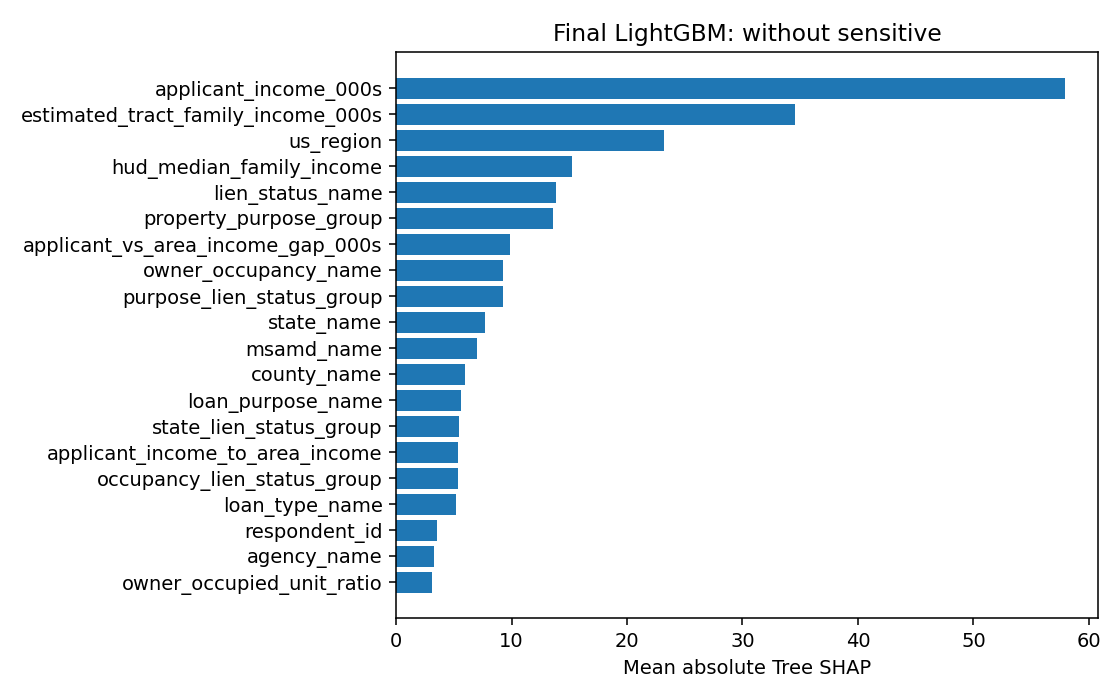

with_sensitive


,source_feature,feature_origin,mean_absolute_shap
0,applicant_income_000s,original_numeric,68.619496
1,estimated_tract_family_income_000s,stage4b_engineered,31.200717
2,us_region,original_categorical,22.720301
3,property_purpose_group,stage4b_engineered,14.085515
4,hud_median_family_income,original_numeric,13.748751
5,lien_status_name,original_categorical,11.529874
6,purpose_lien_status_group,stage4b_engineered,10.091529
7,msamd_name,high_cardinality,9.439810
8,owner_occupancy_name,original_categorical,8.379016
9,occupancy_lien_status_group,stage4b_engineered,7.245489


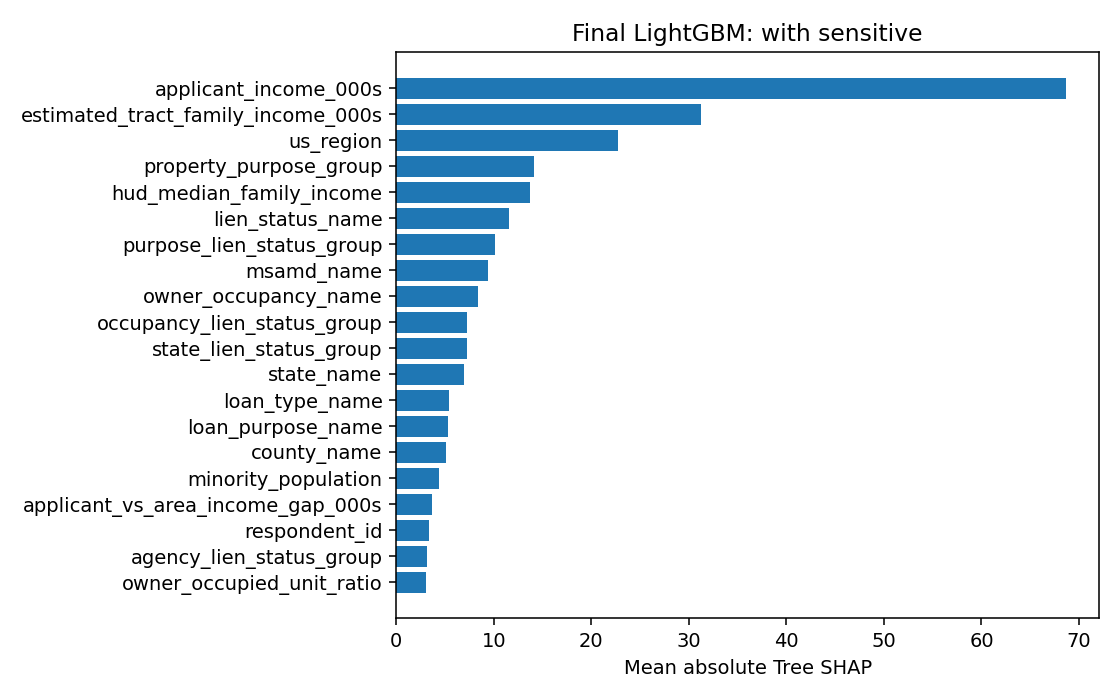

In [42]:
ids = show_csv('artifacts/features/stage4/lightgbm/stage4h_shap_row_ids.csv', ['row_id'], 5)
for mode in ['without_sensitive','with_sensitive']:
    print(mode)
    show_csv(f'artifacts/features/stage4/lightgbm/stage4h_shap_top20_{mode}.csv', ['source_feature','feature_origin','mean_absolute_shap'], 10)
    display(Image(filename=str(ROOT / f'artifacts/figures/stage4/lightgbm/stage4h_shap_summary_{mode}.png')))

### 42. Previous-Stage Reference

Reason: This section checks the saved evidence for Previous-Stage Reference.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: OOF and Final Selection results are labelled as different designs.

In [43]:
show_csv('artifacts/results/stage4/lightgbm/final/lightgbm_previous_stage_reference.csv', ['stage','model_name','evaluation_scheme','evaluation_rows','sensitive_mode','mae','rmse','rmsle','r_squared','runtime_seconds'], 10)

,stage,model_name,evaluation_scheme,evaluation_rows,sensitive_mode,mae,rmse,rmsle,r_squared,runtime_seconds
0,Stage 2,lasso,saved-fold OOF,399788,without_sensitive,72.230441,245.237341,0.441602,0.404243,65.342005
1,Stage 3,hist_gradient_boosting,saved-fold OOF,399788,without_sensitive,64.275669,249.121627,0.395075,0.385222,40.657902
2,Stage 4D-E,catboost,Final Selection validation,25000,without_sensitive,63.376185,130.272187,0.390619,0.693632,320.629190
3,Stage 4G-H,lightgbm,Final Selection validation,25000,without_sensitive,64.456751,131.956170,0.445551,0.685660,14.205618


,stage,model_name,sensitive_mode,evaluation_scheme,evaluation_rows,mae,rmse,rmsle,r_squared,runtime_seconds,prediction_runtime_seconds,directly_comparable_across_all_rows,comparison_note,locked_test_note
0,Stage 2,lasso,without_sensitive,saved-fold OOF,399788,72.230441,245.237341,0.441602,0.404243,65.342005,1.740441,False,"OOF, Discovery validation, and Final Selection...",The locked Test Set will later provide the com...
1,Stage 3,hist_gradient_boosting,without_sensitive,saved-fold OOF,399788,64.275669,249.121627,0.395075,0.385222,40.657902,9.120964,False,"OOF, Discovery validation, and Final Selection...",The locked Test Set will later provide the com...
2,Stage 4D-E,catboost,without_sensitive,Final Selection validation,25000,63.376185,130.272187,0.390619,0.693632,320.629190,0.384864,False,"OOF, Discovery validation, and Final Selection...",The locked Test Set will later provide the com...
3,Stage 4G-H,lightgbm,without_sensitive,Final Selection validation,25000,64.456751,131.956170,0.445551,0.685660,14.205618,2.302812,False,Stage 2 and Stage 3 use saved-fold OOF. CatBoo...,The locked Test Set will provide the final com...


### 43. LightGBM Artifact Summary

Reason: This section checks the saved evidence for LightGBM Artifact Summary.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: All required LightGBM artifact groups are present.

In [44]:
show_json('artifacts/reports/stage4h_artifact_summary.json')

{'stage_id': 'stage4h',
 'lightgbm_registry_rows': 13,
 'candidate_checkpoints': 4,
 'feature_confirmation_checkpoints': 3,
 'tuning_checkpoints': 3,
 'sensitive_validation_checkpoints': 1,
 'full_train_checkpoints': 2,
 'final_bundles': 2,
 'native_boosters': 2,
 'reload_pass_count': 2,
 'importance_modes': 2,
 'shap_modes': 2,
 'test_predictions': 0,
 'status': 'PASS'}

{'stage_id': 'stage4h',
 'lightgbm_registry_rows': 13,
 'candidate_checkpoints': 4,
 'feature_confirmation_checkpoints': 3,
 'tuning_checkpoints': 3,
 'sensitive_validation_checkpoints': 1,
 'full_train_checkpoints': 2,
 'final_bundles': 2,
 'native_boosters': 2,
 'reload_pass_count': 2,
 'importance_modes': 2,
 'shap_modes': 2,
 'test_predictions': 0,
 'status': 'PASS'}

### 44. Final Verification

Reason: This section checks the saved evidence for Final Verification.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: Final LightGBM verification reports PASS after the independent review and accepted repairs.

In [45]:
show_json('artifacts/reports/stage4h_verification.json', ['stage_name','checks','reviewer','status','next_step'])

{'stage_name': 'Stage 4H — Final LightGBM Sensitive Comparison and Full-Train Models',
 'checks': {'previous_required_stages_pass': True,
  'protected_852_files_unchanged': True,
  'test_remains_locked': True,
  'discovery_sample_valid': True,
  'feature_confirmation_sample_valid': True,
  'final_selection_sample_valid': True,
  'samples_mutually_disjoint_train_only': True,
  'stage4f_candidate_budget_respected': True,
  'stage4f_gate_pass': True,
  'stage4g_confirmation_budget_respected': True,
  'stage4g_tuning_exactly_three': True,
  'stage4g_gate_pass': True,
  'all_selection_non_sensitive': True,
  'non_sensitive_validation_model_reused': True,
  'exactly_one_sensitive_validation_fit': True,
  'same_rows_and_frozen_configuration': True,
  'two_full_train_models_saved': True,
  'both_full_train_all_399788_rows': True,
  'zero_test_rows_in_full_train': True,
  'two_complete_bundles_and_native_boosters': True,
  'two_clean_reload_tests_pass': True,
  'final_importance_both_modes': Tr

{'stage': 'stage4h',
 'stage_name': 'Stage 4H — Final LightGBM Sensitive Comparison and Full-Train Models',
 'created_at_utc': '2026-07-14T18:20:01.139842+00:00',
 'protected_hash_report': 'artifacts/manifests/stage4/lightgbm/stage4h_protected_hashes_after.json',
 'reviewer': {'report': 'artifacts/reports/stage4h_reviewer.md',
  'adjudication': 'artifacts/reports/stage4h_reviewer_adjudication.md',
  'critical_issues': 0,
  'major_issues': 2,
  'accepted_major_fixes': 2,
  'status': 'PASS_AFTER_REPAIR'},
 'registry': {'rows': 256,
  'unique_ids': 256,
  'lightgbm_rows': 13,
  'prior_rows': 243,
  'prior_registry_sha256_restored': '9a7aee16017c58b45313d68cab7067bbe9b683331a7fcd9e4096f241f9941bbd'},
 'checks': {'previous_required_stages_pass': True,
  'protected_852_files_unchanged': True,
  'test_remains_locked': True,
  'discovery_sample_valid': True,
  'feature_confirmation_sample_valid': True,
  'final_selection_sample_valid': True,
  'samples_mutually_disjoint_train_only': True,
  's

### 45. LightGBM Track Completion Note

Reason: This section checks the saved evidence for LightGBM Track Completion Note.

Interpretation: The output below is loaded from a validated LightGBM artifact. No model is fitted in this Notebook.

Conclusion: The Notebook evidence is complete without running XGBoost.

In [46]:
display(Markdown('The complete LightGBM track reports PASS. Test is still locked, and XGBoost has not started.'))
print({'cache_only': CACHE_ONLY, 'fit_calls': 0, 'next_step': 'Begin Stage 4I — Initial XGBoost Model and Importance Analysis.'})

The complete LightGBM track reports PASS. Test is still locked, and XGBoost has not started.

{'cache_only': True, 'fit_calls': 0, 'next_step': 'Begin Stage 4I — Initial XGBoost Model and Importance Analysis.'}
